# ICU Length-of-Stay Saved Models Demo

This notebook demonstrates saved final classifiers from our STATS 170B capstone project. It loads pretrained model artifacts, applies them to a small synthetic ICU sample with the same feature schema, and generates example evaluation plots. The restricted MIMIC-IV source data is not included, and the full feature-engineering and training pipeline was run offline.

In [1]:
from pathlib import Path
import json

import joblib
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score, roc_auc_score

PROJECT_ROOT = Path.cwd()
DATA_PATH = PROJECT_ROOT / "data" / "sample" / "fake_icu_los_sample.csv"
MODEL_DIR = PROJECT_ROOT / "models" / "saved"

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({
    "font.size": 13,
    "axes.titlesize": 16,
    "axes.labelsize": 14,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 12,
    "legend.title_fontsize": 12,
    "figure.titlesize": 17,
})

## Load synthetic sample and saved artifacts

The sample rows are hand-created synthetic examples. They are not patient records; they only let the notebook show saved-model inference without redistributing restricted data. Metrics computed on these rows are demonstration checks only and should not be interpreted as held-out clinical performance estimates.

In [2]:
def load_metadata(name):
    with (MODEL_DIR / name).open() as f:
        return json.load(f)

model_specs = {
    "Binary Random Forest": load_metadata("random_forest_short_stay_model_metadata.json"),
    "Binary Logistic Regression": load_metadata("logistic_regression_short_stay_model_metadata.json"),
    "Three-way Random Forest": load_metadata("random_forest_three_class_los_model_metadata.json"),
    "Three-way Logistic Regression": load_metadata("logistic_regression_three_class_los_model_metadata.json"),
}

models = {
    label: joblib.load(PROJECT_ROOT / meta["model_file"])
    for label, meta in model_specs.items()
}

demo = pd.read_csv(DATA_PATH)
print(f"Loaded {len(demo)} synthetic rows from {DATA_PATH.relative_to(PROJECT_ROOT)}")
for label, meta in model_specs.items():
    print(f"{label}: {meta['model_file']}")

Loaded 24 synthetic rows from data/sample/fake_icu_los_sample.csv
Binary Random Forest: models/saved/random_forest_short_stay_model_compressed.joblib
Binary Logistic Regression: models/saved/logistic_regression_short_stay_model.joblib
Three-way Random Forest: models/saved/random_forest_three_class_los_model_compressed.joblib
Three-way Logistic Regression: models/saved/logistic_regression_three_class_los_model.joblib


In [3]:
pd.DataFrame([
    {
        "model": label,
        "target": meta["target"],
        "classes": ", ".join(meta["classes"]),
        "offline_training_rows": meta["training_rows"],
        "offline_test_rows": meta["test_rows"],
    }
    for label, meta in model_specs.items()
])

,model,target,classes,offline_training_rows,offline_test_rows
0,Binary Random Forest,los_class,"longer, short",75555,18889
1,Binary Logistic Regression,los_class,"longer, short",75555,18889
2,Three-way Random Forest,three_way_los_class,"long, medium, short",75554,18890
3,Three-way Logistic Regression,three_way_los_class,"long, medium, short",75554,18890


## Binary short-stay classification

These saved models predict whether an ICU stay is `short` versus `longer`. The labels below are synthetic demonstration labels, so the scores are only a runnable example of the model interface. Final model evaluation and interpretation are reported in the final project report.

In [4]:
def feature_frame(meta):
    return demo.reindex(columns=meta["feature_columns"])

def probability_for_class(model, X, class_name):
    class_index = list(model.classes_).index(class_name)
    return model.predict_proba(X)[:, class_index]

binary_true = demo["demo_true_los_class"]
binary_rows = []
binary_predictions = {}

for label in ["Binary Random Forest", "Binary Logistic Regression"]:
    model = models[label]
    X = feature_frame(model_specs[label])
    pred = model.predict(X)
    proba_short = probability_for_class(model, X, "short")
    binary_predictions[label] = {"prediction": pred, "proba_short": proba_short}
    binary_rows.append({
        "model": label.replace("Binary ", ""),
        "accuracy": accuracy_score(binary_true, pred),
        "f1_short": f1_score(binary_true, pred, pos_label="short"),
        "roc_auc_short": roc_auc_score((binary_true == "short").astype(int), proba_short),
    })

binary_metrics = pd.DataFrame(binary_rows).set_index("model")
binary_metrics

,accuracy,f1_short,roc_auc_short
model,,,
Random Forest,0.875000,0.880000,0.846154
Logistic Regression,0.666667,0.714286,0.559441


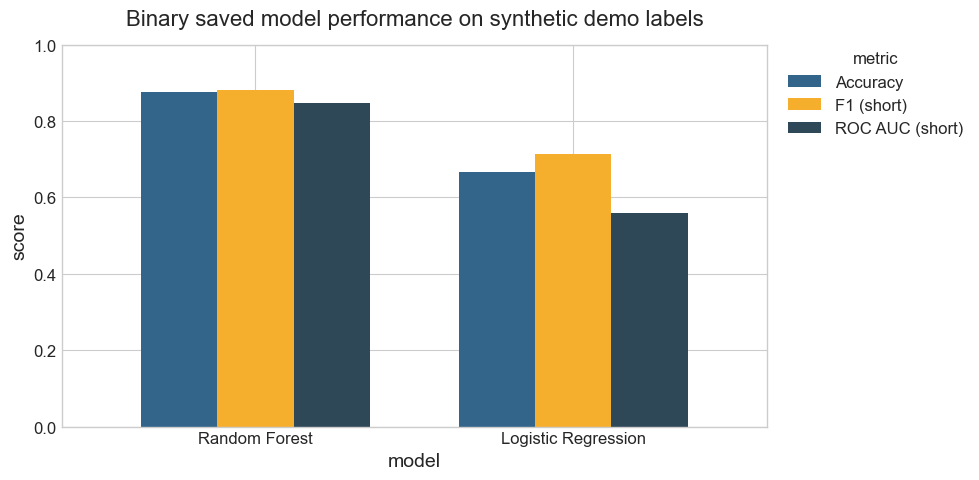

In [5]:
binary_plot = binary_metrics[["accuracy", "f1_short", "roc_auc_short"]].rename(columns={
    "accuracy": "Accuracy",
    "f1_short": "F1 (short)",
    "roc_auc_short": "ROC AUC (short)",
})

ax = binary_plot.plot(
    kind="bar", figsize=(10, 5), width=0.72, color=["#33658A", "#F6AE2D", "#2F4858"]
)
ax.set_ylim(0, 1)
ax.set_ylabel("score")
ax.set_title("Binary saved model performance on synthetic demo labels", pad=14)
ax.legend(title="metric", loc="upper left", bbox_to_anchor=(1.02, 1), borderaxespad=0)
ax.tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.show()

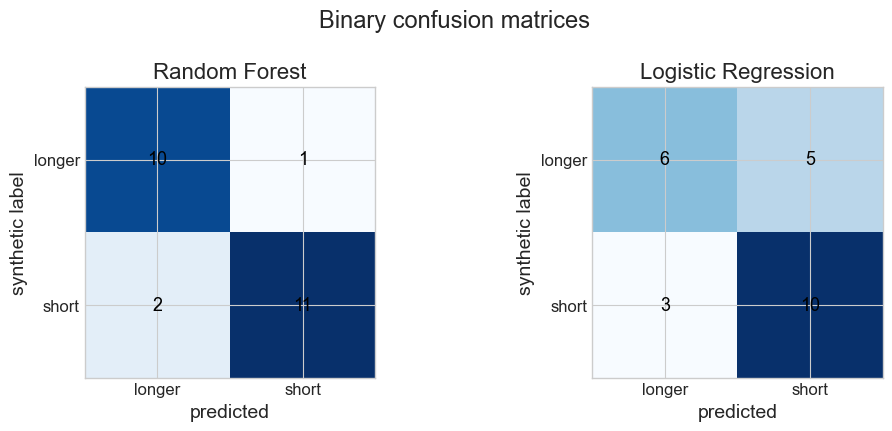

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.4))
labels = ["longer", "short"]
for ax, label in zip(axes, ["Binary Random Forest", "Binary Logistic Regression"]):
    cm = confusion_matrix(binary_true, binary_predictions[label]["prediction"], labels=labels)
    ax.imshow(cm, cmap="Blues")
    ax.set_title(label.replace("Binary ", ""))
    ax.set_xticks(range(len(labels)), labels=labels)
    ax.set_yticks(range(len(labels)), labels=labels)
    ax.set_xlabel("predicted")
    ax.set_ylabel("synthetic label")
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, cm[i, j], ha="center", va="center", color="black", fontsize=13)
fig.suptitle("Binary confusion matrices")
plt.tight_layout()
plt.show()

In [7]:
example_cols = ["demo_stay_id", "anchor_age", "first_careunit", "admission_type", "demo_true_los_class"]
examples = demo[example_cols].copy()
for label in ["Binary Random Forest", "Binary Logistic Regression"]:
    short_name = label.replace("Binary ", "")
    examples[f"{short_name} prediction"] = binary_predictions[label]["prediction"]
    examples[f"{short_name} P(short)"] = binary_predictions[label]["proba_short"].round(3)
examples.head(8)

,demo_stay_id,anchor_age,first_careunit,admission_type,demo_true_los_class,Random Forest prediction,Random Forest P(short),Logistic Regression prediction,Logistic Regression P(short)
0,fake_001,62.643,MICU,EMERGENCY,longer,longer,0.464,short,1.000
1,fake_002,56.621,SICU,URGENT,short,short,0.526,short,0.628
2,fake_003,53.918,CCU,ELECTIVE,longer,longer,0.490,longer,0.426
3,fake_004,71.786,CVICU,EMERGENCY,longer,longer,0.466,short,1.000
4,fake_005,52.945,MICU,URGENT,short,short,0.577,short,1.000
5,fake_006,59.893,SICU,ELECTIVE,short,short,0.632,short,0.715
6,fake_007,65.084,CCU,EMERGENCY,longer,longer,0.386,short,1.000
7,fake_008,69.915,CVICU,URGENT,longer,longer,0.474,longer,0.002


## Three-way length-of-stay classification

These saved models classify ICU length of stay into `short`, `medium`, or `long` buckets. They are loaded from disk exactly like the binary models; no training happens in this notebook. As above, metrics on the synthetic rows verify that the models run and produce interpretable outputs, not held-out clinical performance.

In [8]:
three_true = demo["demo_true_los_class_3way"]
three_rows = []
three_predictions = {}

for label in ["Three-way Random Forest", "Three-way Logistic Regression"]:
    model = models[label]
    X = feature_frame(model_specs[label])
    pred = model.predict(X)
    proba = model.predict_proba(X)
    three_predictions[label] = {"prediction": pred, "proba": proba}
    three_rows.append({
        "model": label.replace("Three-way ", ""),
        "accuracy": accuracy_score(three_true, pred),
        "macro_f1": f1_score(three_true, pred, average="macro"),
        "weighted_f1": f1_score(three_true, pred, average="weighted"),
    })

three_metrics = pd.DataFrame(three_rows).set_index("model")
three_metrics

,accuracy,macro_f1,weighted_f1
model,,,
Random Forest,0.708333,0.695100,0.700393
Logistic Regression,0.458333,0.330864,0.504321


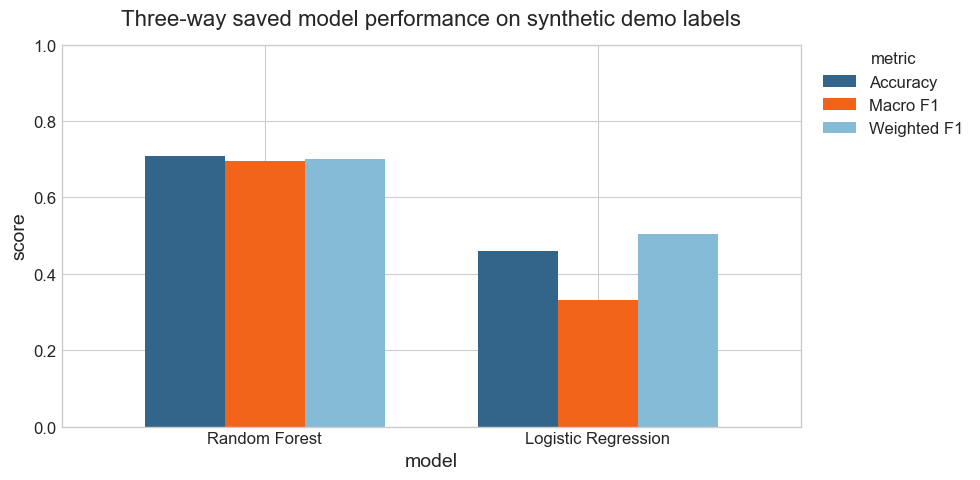

In [9]:
three_plot = three_metrics[["accuracy", "macro_f1", "weighted_f1"]].rename(columns={
    "accuracy": "Accuracy",
    "macro_f1": "Macro F1",
    "weighted_f1": "Weighted F1",
})

ax = three_plot.plot(
    kind="bar", figsize=(10, 5), width=0.72, color=["#33658A", "#F26419", "#86BBD8"]
)
ax.set_ylim(0, 1)
ax.set_ylabel("score")
ax.set_title("Three-way saved model performance on synthetic demo labels", pad=14)
ax.legend(title="metric", loc="upper left", bbox_to_anchor=(1.02, 1), borderaxespad=0)
ax.tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.show()

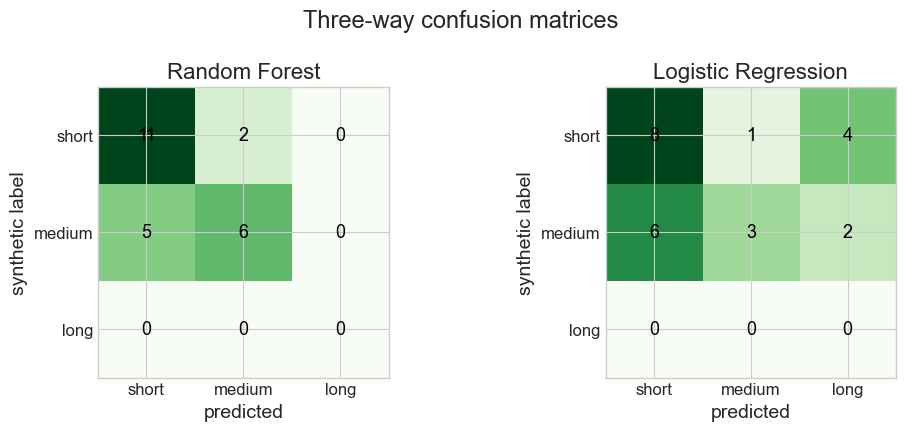

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.4))
labels = ["short", "medium", "long"]
for ax, label in zip(axes, ["Three-way Random Forest", "Three-way Logistic Regression"]):
    cm = confusion_matrix(three_true, three_predictions[label]["prediction"], labels=labels)
    ax.imshow(cm, cmap="Greens")
    ax.set_title(label.replace("Three-way ", ""))
    ax.set_xticks(range(len(labels)), labels=labels)
    ax.set_yticks(range(len(labels)), labels=labels)
    ax.set_xlabel("predicted")
    ax.set_ylabel("synthetic label")
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, cm[i, j], ha="center", va="center", color="black", fontsize=13)
fig.suptitle("Three-way confusion matrices")
plt.tight_layout()
plt.show()

In [11]:
three_examples = demo[["demo_stay_id", "anchor_age", "first_careunit", "admission_type", "demo_true_los_class_3way"]].copy()
for label in ["Three-way Random Forest", "Three-way Logistic Regression"]:
    model = models[label]
    short_name = label.replace("Three-way ", "")
    three_examples[f"{short_name} prediction"] = three_predictions[label]["prediction"]
    for class_name in ["short", "medium", "long"]:
        if class_name in list(model.classes_):
            idx = list(model.classes_).index(class_name)
            three_examples[f"{short_name} P({class_name})"] = three_predictions[label]["proba"][:, idx].round(3)
three_examples.head(8)

,demo_stay_id,anchor_age,first_careunit,admission_type,demo_true_los_class_3way,Random Forest prediction,Random Forest P(short),Random Forest P(medium),Random Forest P(long),Logistic Regression prediction,Logistic Regression P(short),Logistic Regression P(medium),Logistic Regression P(long)
0,fake_001,62.643,MICU,EMERGENCY,medium,short,0.381,0.313,0.306,short,1.000,0.000,0.000
1,fake_002,56.621,SICU,URGENT,medium,short,0.443,0.366,0.191,short,0.393,0.357,0.251
2,fake_003,53.918,CCU,ELECTIVE,medium,short,0.412,0.402,0.186,medium,0.430,0.545,0.026
3,fake_004,71.786,CVICU,EMERGENCY,short,medium,0.304,0.419,0.277,short,1.000,0.000,0.000
4,fake_005,52.945,MICU,URGENT,medium,short,0.424,0.374,0.202,short,1.000,0.000,0.000
5,fake_006,59.893,SICU,ELECTIVE,short,short,0.551,0.244,0.205,long,0.372,0.074,0.553
6,fake_007,65.084,CCU,EMERGENCY,medium,medium,0.281,0.396,0.323,short,1.000,0.000,0.000
7,fake_008,69.915,CVICU,URGENT,medium,medium,0.381,0.396,0.222,medium,0.001,0.730,0.268
